In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Read Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Predictive Maintenance /predictive_maintenance.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [5]:
df.tail(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,No Failure
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,No Failure
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,No Failure
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,No Failure
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,No Failure


In [6]:
df.shape

(10000, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [8]:
# Categorical features
df.describe(include="O")

,Product ID,Type,Failure Type
count,10000,10000,10000
unique,10000,3,6
top,M24859,L,No Failure
freq,1,6000,9652


In [9]:
# Numerical features
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


# 2. Check Missing Value

In [10]:
df.isna().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Target,0
Failure Type,0


# 3. Check Duplicated Data

In [11]:
df[df.duplicated()]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type


# 4. Distribution Plot

In [12]:
df_numeric = df.select_dtypes(include=['int', 'float'])
print(df_numeric.columns)

Index(['UDI', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target'],
      dtype='object')


In [13]:
# Numerical variable
def plot_hist(variable):
    plt.figure(figsize = (6, 3))
    plt.hist(df[variable], bins = 50)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist".format(variable))
    plt.show()

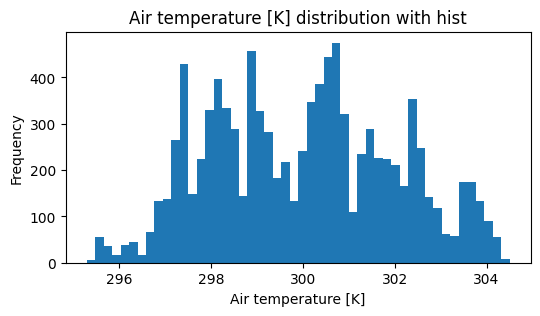

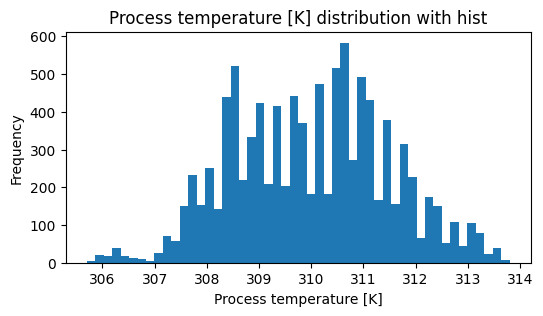

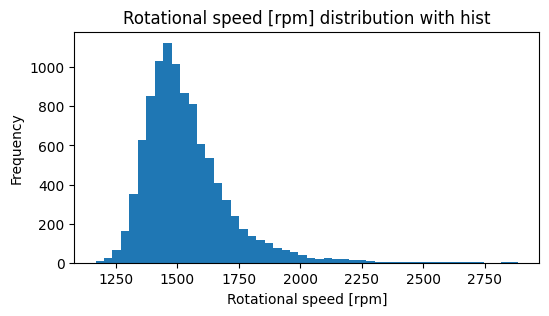

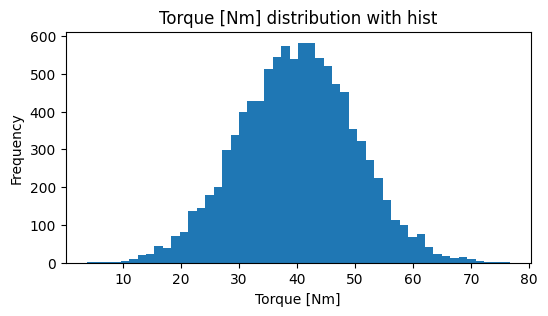

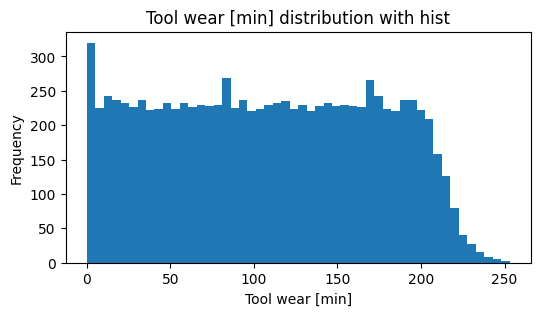

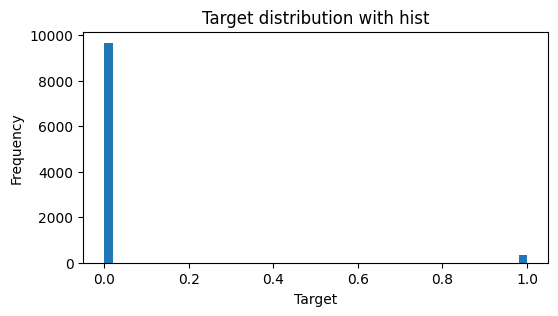

In [14]:
category1 = ['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target']
for c in category1:
    plot_hist(c)

In [15]:
# Categorical variable
def bar_plot(variable):

    # get feature
    var = df[variable]
    # count number of categorical variable(value/sample)
    varValue = var.value_counts()

    # visualize
    plt.figure(figsize = (6,3))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    #print("{}: \n {}".format(variable,varValue))

In [16]:
df_categorical = df.select_dtypes(include=['object'])
print(df_categorical.columns)

Index(['Product ID', 'Type', 'Failure Type'], dtype='object')


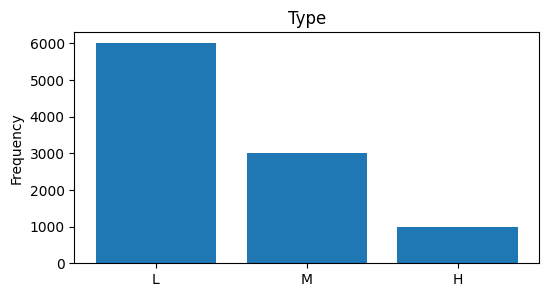

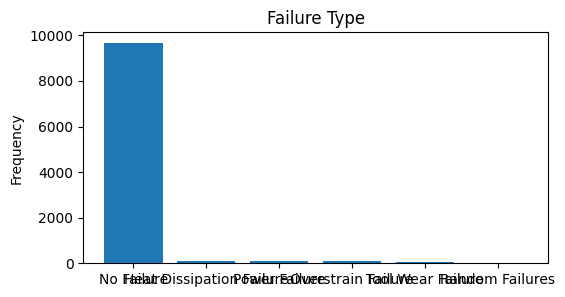

In [17]:
# Categorical variable
category2 = ['Type', 'Failure Type']
for c in category2:
    bar_plot(c)

In [18]:
# Class distribution
df['Failure Type'].value_counts()

,count
Failure Type,
No Failure,9652
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
Random Failures,18


In [19]:
df['Target'].value_counts()

,count
Target,
0,9661
1,339


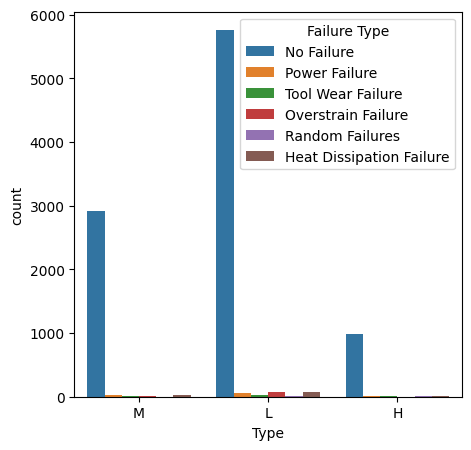

In [20]:
# Feature by target
columns = ['Type']

plt.figure(figsize=(5, 5))
sns.countplot(x='Type', data=df, hue='Failure Type')
plt.show()

# 5. Drop Unnecessary Column

In [21]:
# Because column UDI and Product ID isn't necessary for prediction, then drop it
df = df.drop(columns=['UDI', 'Product ID', 'Target'])
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type
0,M,298.1,308.6,1551,42.8,0,No Failure
1,L,298.2,308.7,1408,46.3,3,No Failure
2,L,298.1,308.5,1498,49.4,5,No Failure
3,L,298.2,308.6,1433,39.5,7,No Failure
4,L,298.2,308.7,1408,40.0,9,No Failure


In [52]:
df.tail(5)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type,temp_diff,temp_ratio,rpm_diff,rpm_ratio
9995,0,298.8,308.4,1604,29.5,14,0,9.6,1.032129,-1574.5,0.018392
9996,2,298.9,308.4,1632,31.8,17,0,9.5,1.031783,-1600.2,0.019485
9997,0,299.0,308.6,1645,33.4,22,0,9.6,1.032107,-1611.6,0.020304
9998,2,299.0,308.7,1408,48.5,25,0,9.7,1.032441,-1359.5,0.034446
9999,0,299.0,308.7,1500,40.2,30,0,9.7,1.032441,-1459.8,0.026800


In [22]:
df.shape

(10000, 7)

# 6. Categorical to Numerical Value

In [23]:
# Convert categorical to numerical features
df['Type'].unique()

array(['M', 'L', 'H'], dtype=object)

In [24]:
pd.set_option('future.no_silent_downcasting', True)
df['Type'] = df['Type'].replace(to_replace=[i for i in df['Type'].unique()],
                                value=[i for i in range(3)], inplace=False).astype(int)

In [25]:
df['Failure Type'] = df['Failure Type'].replace(to_replace=[i for i in df['Failure Type'].unique()],
                                value=[i for i in range(6)], inplace=False).astype(int)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  int64  
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Failure Type             10000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 547.0 KB


In [53]:
df['Failure Type'].value_counts()

,count
Failure Type,
0,9652
5,112
1,95
3,78
2,45
4,18


In [27]:
from imblearn.over_sampling import SMOTE

X = df.drop('Failure Type', axis=1)
y = df['Failure Type']

# Apply random oversampling
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine X_resampled and y_resampled back into a DataFrame if needed
df_resampled = pd.concat([X_resampled, y_resampled], axis=1)

In [28]:
# Class distribution
df_resampled['Failure Type'].value_counts()

,count
Failure Type,
0,9652
1,9652
2,9652
3,9652
4,9652
5,9652


In [50]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type,temp_diff,temp_ratio,rpm_diff,rpm_ratio
0,0,298.1,308.6,1551,42.8,0,0,10.5,1.035223,-1508.2,0.027595
1,1,298.2,308.7,1408,46.3,3,0,10.5,1.035211,-1361.7,0.032884
2,1,298.1,308.5,1498,49.4,5,0,10.4,1.034888,-1448.6,0.032977
3,1,298.2,308.6,1433,39.5,7,0,10.4,1.034876,-1393.5,0.027565
4,1,298.2,308.7,1408,40.0,9,0,10.5,1.035211,-1368.0,0.028409
...,...,...,...,...,...,...,...,...,...,...,...
9995,0,298.8,308.4,1604,29.5,14,0,9.6,1.032129,-1574.5,0.018392
9996,2,298.9,308.4,1632,31.8,17,0,9.5,1.031783,-1600.2,0.019485
9997,0,299.0,308.6,1645,33.4,22,0,9.6,1.032107,-1611.6,0.020304
9998,2,299.0,308.7,1408,48.5,25,0,9.7,1.032441,-1359.5,0.034446


# 7. Correlation Heatmap

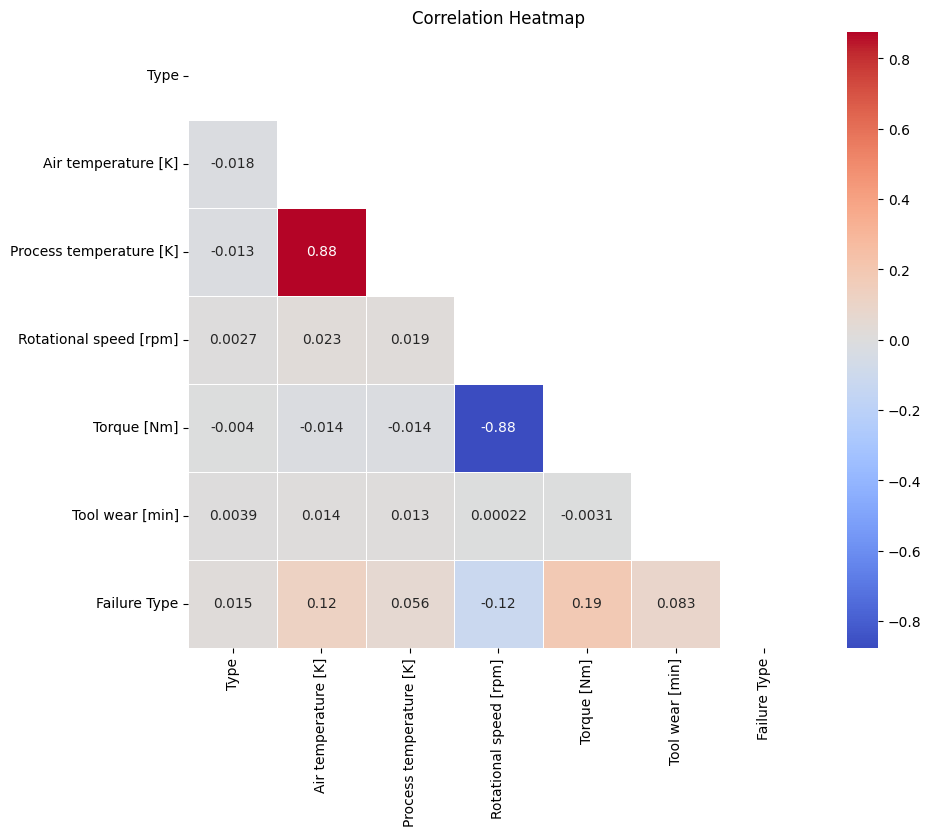

In [29]:
# Calculate the correlation matrix
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create a heatmap
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [30]:
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['temp_ratio'] = df['Process temperature [K]'] / df['Air temperature [K]']

In [31]:
df['rpm_diff'] = df['Torque [Nm]'] - df['Rotational speed [rpm]']
df['rpm_ratio'] = df['Torque [Nm]'] / df['Rotational speed [rpm]']

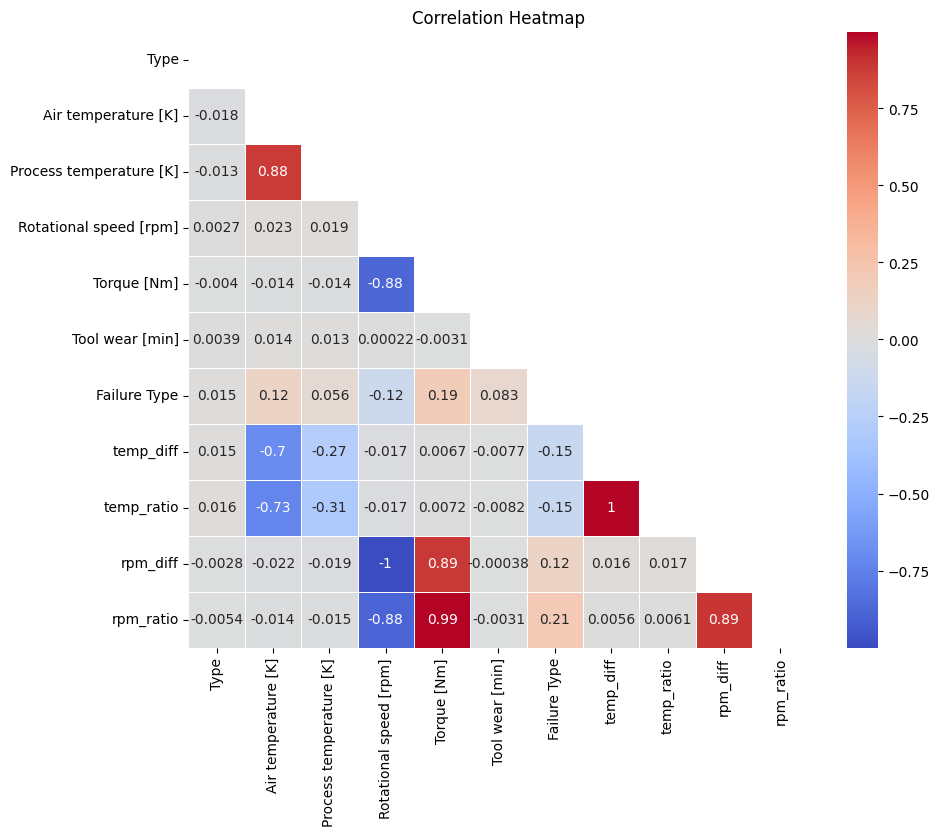

In [32]:
# Calculate the correlation matrix
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create a heatmap
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [49]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type,temp_diff,temp_ratio,rpm_diff,rpm_ratio
0,0,298.1,308.6,1551,42.8,0,0,10.5,1.035223,-1508.2,0.027595
1,1,298.2,308.7,1408,46.3,3,0,10.5,1.035211,-1361.7,0.032884
2,1,298.1,308.5,1498,49.4,5,0,10.4,1.034888,-1448.6,0.032977
3,1,298.2,308.6,1433,39.5,7,0,10.4,1.034876,-1393.5,0.027565
4,1,298.2,308.7,1408,40.0,9,0,10.5,1.035211,-1368.0,0.028409
...,...,...,...,...,...,...,...,...,...,...,...
9995,0,298.8,308.4,1604,29.5,14,0,9.6,1.032129,-1574.5,0.018392
9996,2,298.9,308.4,1632,31.8,17,0,9.5,1.031783,-1600.2,0.019485
9997,0,299.0,308.6,1645,33.4,22,0,9.6,1.032107,-1611.6,0.020304
9998,2,299.0,308.7,1408,48.5,25,0,9.7,1.032441,-1359.5,0.034446


# 8. Modelling

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

In [34]:
import re
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
df_resampled.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in df_resampled.columns.values]
df_resampled.columns = df_resampled.columns.str.replace(' ', '_')

X = df_resampled.drop('Failure_Type', axis=1)
y = df_resampled['Failure_Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type,temp_diff,temp_ratio,rpm_diff,rpm_ratio
0,0,298.1,308.6,1551,42.8,0,0,10.5,1.035223,-1508.2,0.027595
1,1,298.2,308.7,1408,46.3,3,0,10.5,1.035211,-1361.7,0.032884
2,1,298.1,308.5,1498,49.4,5,0,10.4,1.034888,-1448.6,0.032977
3,1,298.2,308.6,1433,39.5,7,0,10.4,1.034876,-1393.5,0.027565
4,1,298.2,308.7,1408,40.0,9,0,10.5,1.035211,-1368.0,0.028409
...,...,...,...,...,...,...,...,...,...,...,...
9995,0,298.8,308.4,1604,29.5,14,0,9.6,1.032129,-1574.5,0.018392
9996,2,298.9,308.4,1632,31.8,17,0,9.5,1.031783,-1600.2,0.019485
9997,0,299.0,308.6,1645,33.4,22,0,9.6,1.032107,-1611.6,0.020304
9998,2,299.0,308.7,1408,48.5,25,0,9.7,1.032441,-1359.5,0.034446


In [35]:
models = [
    ('Logistic Regression', LogisticRegression()),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Support Vector Machines', SVC()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier()),
    ('AdaBoost', AdaBoostClassifier()),
    ('Gradient Boosting', GradientBoostingClassifier()),
    ('Naive Bayes', GaussianNB()),
    ('Neural Network', MLPClassifier())
]


In [36]:
# Function for evaluate model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    return accuracy, precision, recall, f1


In [37]:
# Train and evaluate model
results = []
for name, model in models:
    model.fit(X_train, y_train)
    accuracy, precision, recall, f1 = evaluate_model(model, X_test,y_test)
    results.append([name, accuracy, precision, recall, f1])

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
 

In [38]:
# Function for evaluate model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    return accuracy, precision, recall, f1

In [39]:
# Show result on table
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy','Precision', 'Recall', 'F1 Score'])
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770526,0.764529,0.770526,0.763518
1,K-Nearest Neighbors,0.949150,0.953708,0.949150,0.946577
2,Support Vector Machines,0.704481,0.717310,0.704481,0.696646
3,Decision Tree,0.985323,0.985322,0.985323,0.985242
4,Random Forest,0.992316,0.992410,0.992316,0.992265
5,AdaBoost,0.515065,0.446385,0.515065,0.449327
6,Gradient Boosting,0.969265,0.970188,0.969265,0.968610
7,Naive Bayes,0.763274,0.759681,0.763274,0.755598
8,Neural Network,0.758180,0.767223,0.758180,0.750091


In [40]:
# # Visualization using bar plot
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Model', y='Accuracy', data=results_df)
# plt.title('Comparation of Model')
# plt.xticks(rotation=45)
# plt.ylabel('Accuracy')
# plt.show()

# 9. Bagging Algorithm

In [41]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.5 MB/s eta 0:00:00


In [42]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [43]:
import re
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
df_resampled.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in df_resampled.columns.values]
df_resampled.columns = df_resampled.columns.str.replace(' ', '_')

X = df_resampled.drop('Failure Type', axis=1)
y = df_resampled['Failure Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
# Initialize models
models = [
    ('AdaBoost', AdaBoostClassifier()),
    ('Gradient Boosting', GradientBoostingClassifier()),
    ('XGBoost', XGBClassifier()),
    ('LightGBM', LGBMClassifier(force_row_wise=True)),
    ('CatBoost', CatBoostClassifier(silent=True))
]

# Evaluate models
results = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append((name, accuracy, precision, recall, f1))

# Create comparison table
comparison_df = pd.DataFrame(results, columns=['Model', 'Accuracy','Precision', 'Recall', 'F1 Score'])

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[LightGBM] [Info] Total Bins 1277
[LightGBM] [Info] Number of data points in the train set: 46329, number of used features: 6
[LightGBM] [Info] Start training from score -1.795847
[LightGBM] [Info] Start training from score -1.783955
[LightGBM] [Info] Start training from score -1.792472
[LightGBM] [Info] Start training from score -1.796628
[LightGBM] [Info] Start training from score -1.789237
[LightGBM] [Info] Start training from score -1.792472


In [45]:
 comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,AdaBoost,0.515065,0.446385,0.515065,0.449327
1,Gradient Boosting,0.969265,0.970188,0.969265,0.968610
2,XGBoost,0.993870,0.993940,0.993870,0.993842
3,LightGBM,0.994129,0.994190,0.994129,0.994106
4,CatBoost,0.989813,0.989992,0.989813,0.989716


# 10. Ensemble Method

In [46]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier

# Model for ensemble methods
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42,algorithm='SAMME')
logistic_regression = LogisticRegression(random_state=42, max_iter=2000)

# Model stacking
estimators = [('random_forest', random_forest), ('adaboost', adaboost), ('logistic_regression', logistic_regression)]
stacking = StackingClassifier(estimators=estimators,final_estimator=LogisticRegression(max_iter = 2000))
stacking.fit(X_train, y_train)
y_pred = stacking.predict(X_test)

# Performance evaluation
accuracy = np.mean(y_pred == y_test)
print(f'Accuracy: {accuracy:.4f}')

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Accuracy: 0.9959


In [48]:
import joblib  # For saving/loading models
# Save the model
joblib.dump(model, 'predictive_analysis_model.pkl')
print("predictive_analysis_model.pkl'")

predictive_analysis_model.pkl'
